# SMAP & Sentinel-1 soil moisture — hands-on

Load Sentinel-1 radar in Google Earth Engine, build a VV/VH ratio and a Radar Vegetation Index, map the March 2019 Missouri River flood, and view SMAP soil moisture at 9 km, 3 km and 1 km over the U.S. Corn Belt.

Run the cells in order. Edit the areas of interest in the setup cell to study a different region. A Google Earth Engine account is required.


## 0. Setup


In [ ]:
!pip install -q geemap rasterio

In [ ]:
import ee, geemap

PROJECT_ID = "ee-arunavnanda7"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

Map = geemap.Map(center=[41.7, -91.5], zoom=7)
Map

In [ ]:
# Areas of interest (edit to study your own region)
AG_AOI    = ee.Geometry.Rectangle([-93.9, 41.9, -93.2, 42.5])   # central Iowa
FLOOD_AOI = ee.Geometry.Rectangle([-96.3, 40.4, -95.4, 41.4])   # Missouri River, NE/IA
CORN_BELT = (-99, 37, -82, 46)                                  # lon W, lat S, lon E, lat N

## 1. Sentinel-1 backscatter and the VV/VH ratio

Sentinel-1 records two polarizations, VV and VH, in decibels (dB). VV responds to surface roughness and open water; VH (cross-pol) responds to vegetation. In dB, the VV/VH ratio is a subtraction.


In [ ]:
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
      .filterBounds(AG_AOI).filterDate('2025-06-01', '2025-06-30')
      .filter(ee.Filter.eq('instrumentMode', 'IW'))
      .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
      .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
      .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')))

img = s1.median().clip(AG_AOI)
ratio = img.select('VV').subtract(img.select('VH')).rename('VV_VH')

Map = geemap.Map(center=[42.2, -93.55], zoom=10)
Map.addLayer(img.select('VV'), {'min': -25, 'max': 0},  'VV (dB)')
Map.addLayer(img.select('VH'), {'min': -30, 'max': -5}, 'VH (dB)')
Map.addLayer(ratio, {'min': 0, 'max': 15,
             'palette': ['#2c7bb6', '#ffffbf', '#d7191c']}, 'VV/VH ratio (dB)')
Map

Result:

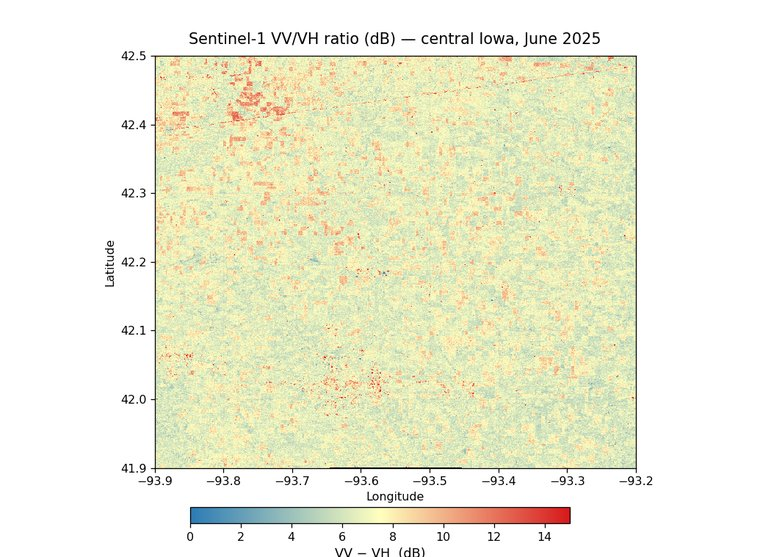


## 2. Radar Vegetation Index (RVI)

RVI estimates vegetation from the two channels. It is defined on linear power, so convert from dB first: sigma0 = 10^(dB/10). Low RVI is bare/smooth ground; high RVI is dense canopy.


In [ ]:
lin = ee.Image(10).pow(img.divide(10))     # dB -> linear power
vv, vh = lin.select('VV'), lin.select('VH')
rvi = vh.multiply(4).divide(vv.add(vh)).rename('RVI')

Map = geemap.Map(center=[42.2, -93.55], zoom=10)
Map.addLayer(rvi, {'min': 0, 'max': 1,
             'palette': ['#8c510a','#d8b365','#f6e8c3','#c7eae5','#5ab4ac','#01665e']}, 'RVI')
Map

Result:

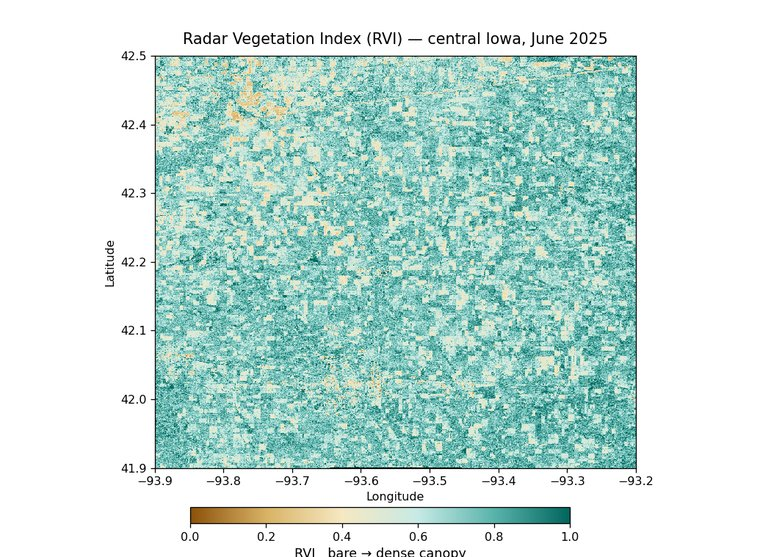


## 3. Flood mapping — March 2019 Missouri River

Open water reflects radar away from the sensor, so flooded ground looks dark. Compare a before and after VH composite and flag pixels that became much darker. Sentinel-1 covers this area on 22 Feb (before) and 18 Mar (peak flood).


In [ ]:
def s1_vh(aoi, d0, d1):
    return (ee.ImageCollection('COPERNICUS/S1_GRD')
            .filterBounds(aoi).filterDate(d0, d1)
            .filter(ee.Filter.eq('instrumentMode', 'IW'))
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
            .select('VH').median().clip(aoi))

pre   = s1_vh(FLOOD_AOI, '2019-02-15', '2019-02-28')
post  = s1_vh(FLOOD_AOI, '2019-03-15', '2019-03-22')
flood = post.lt(-18).And(post.subtract(pre).lt(-3))

Map = geemap.Map(center=[40.95, -95.85], zoom=10)
Map.addLayer(pre,  {'min': -30, 'max': -5}, 'Before VH (22 Feb 2019)')
Map.addLayer(post, {'min': -30, 'max': -5}, 'After VH (18 Mar 2019)')
Map.addLayer(flood.selfMask(), {'palette': ['#1f6feb']}, 'Flooded')
Map

Result:

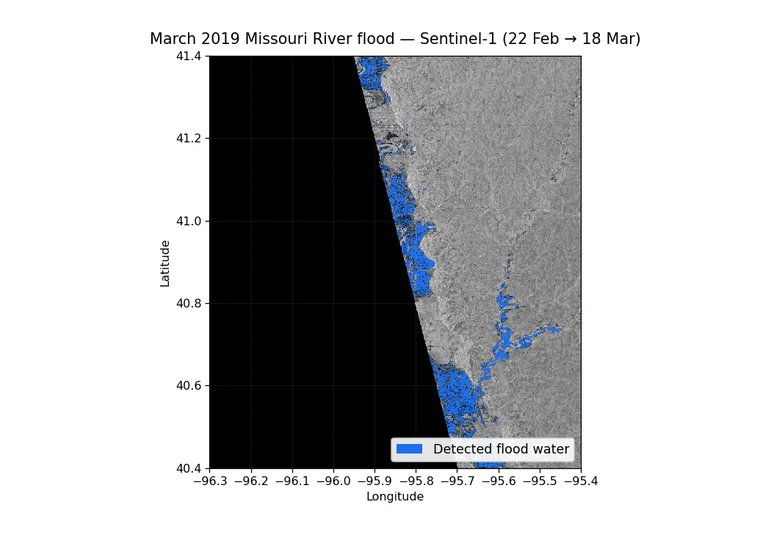


## 4. SMAP soil moisture at 9 km, 3 km and 1 km

Monthly-mean soil moisture (June 2025) over the Corn Belt at the three resolutions, on the official SMAP colour scale. The maps are rasters, so they are drawn as pixels. Coverage is most complete at 9 km and sparsest at 1 km (which needs a Sentinel-1 overpass); spatial detail increases from 9 km to 1 km.


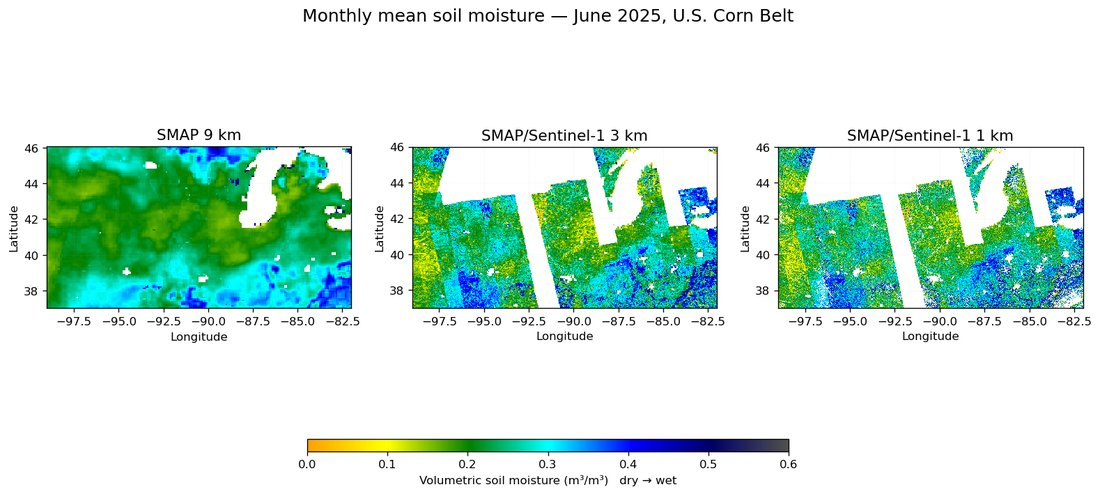

In [1]:
import os, urllib.request, numpy as np, rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.cm import ScalarMappable

SMAP_RGB = [
    (255,161,0), (255,162,0), (255,165,0), (255,167,0), (255,170,0), (255,172,0), (255,174,0), (255,177,0),
    (255,179,0), (255,181,0), (255,184,0), (255,186,0), (255,189,0), (255,191,0), (255,193,0), (255,196,0),
    (255,198,0), (255,200,0), (255,203,0), (255,205,0), (255,208,0), (255,210,0), (255,212,0), (255,215,0),
    (255,217,0), (255,219,0), (255,222,0), (255,224,0), (255,227,0), (255,229,0), (255,231,0), (255,234,0),
    (255,236,0), (255,238,0), (255,241,0), (255,243,0), (255,246,0), (255,248,0), (255,249,0), (255,250,0),
    (255,251,0), (255,253,0), (255,255,0), (255,254,0), (249,252,0), (243,249,0), (237,246,0), (231,243,0),
    (225,240,0), (219,237,0), (213,234,0), (208,231,0), (202,228,0), (196,225,0), (190,222,0), (184,219,0),
    (178,216,0), (172,213,0), (166,210,0), (160,207,0), (154,204,0), (148,201,0), (142,198,0), (136,195,0),
    (130,193,0), (125,190,0), (119,187,0), (113,184,0), (107,181,0), (101,178,0), (95,175,0), (89,172,0),
    (83,169,0), (77,166,0), (71,163,0), (65,160,0), (59,157,0), (53,154,0), (47,151,0), (42,148,0),
    (36,145,0), (30,142,0), (24,139,0), (18,136,0), (12,133,0), (6,130,0), (0,130,0), (0,130,6),
    (0,133,12), (0,136,19), (0,139,25), (0,143,31), (0,146,37), (0,149,44), (0,152,50), (0,155,56),
    (0,158,62), (0,161,68), (0,164,75), (0,168,81), (0,171,87), (0,174,93), (0,177,100), (0,180,106),
    (0,183,112), (0,186,118), (0,189,124), (0,193,131), (0,196,137), (0,199,143), (0,202,149), (0,205,155),
    (0,208,162), (0,211,168), (0,214,174), (0,218,180), (0,221,187), (0,224,193), (0,227,199), (0,230,205),
    (0,233,211), (0,236,218), (0,239,224), (0,243,230), (0,246,236), (0,249,243), (0,252,249), (0,254,255),
    (0,255,255), (0,253,255), (0,249,255), (0,243,255), (0,237,255), (0,231,255), (0,225,255), (0,219,255),
    (0,213,255), (0,208,255), (0,202,255), (0,196,255), (0,190,255), (0,184,255), (0,178,255), (0,172,255),
    (0,166,255), (0,160,255), (0,154,255), (0,148,255), (0,142,255), (0,136,255), (0,130,255), (0,125,255),
    (0,119,255), (0,113,255), (0,107,255), (0,101,255), (0,95,255), (0,89,255), (0,83,255), (0,77,255),
    (0,71,255), (0,65,255), (0,59,255), (0,53,255), (0,47,255), (0,42,255), (0,36,255), (0,30,255),
    (0,24,255), (0,18,255), (0,12,255), (0,6,255), (0,0,255), (0,0,251), (0,0,248), (0,0,244),
    (0,0,241), (0,0,237), (0,0,233), (0,0,230), (0,0,226), (0,0,223), (0,0,219), (0,0,215),
    (0,0,212), (0,0,208), (0,0,205), (0,0,201), (0,0,197), (0,0,194), (0,0,190), (0,0,187),
    (0,0,183), (0,0,179), (0,0,176), (0,0,172), (0,0,168), (0,0,165), (0,0,161), (0,0,158),
    (0,0,154), (0,0,150), (0,0,147), (0,0,143), (0,0,140), (0,0,136), (0,0,132), (0,0,129),
    (0,0,125), (0,0,122), (0,0,118), (0,0,114), (0,0,111), (0,0,107), (0,0,104), (0,0,100),
    (2,2,100), (4,4,100), (6,6,100), (8,8,100), (10,10,100), (12,12,100), (14,14,100), (16,16,100),
    (18,18,100), (20,20,100), (22,22,100), (24,24,100), (26,26,100), (28,28,100), (30,30,100), (32,32,100),
    (34,34,90), (36,36,90), (38,38,90), (40,40,90), (42,42,90), (44,44,90), (46,46,90), (48,48,90),
    (50,50,90), (52,52,90), (54,54,90), (56,56,90), (58,58,90), (60,60,80), (62,62,80), (64,64,80),
    (66,66,80), (68,68,80), (70,70,80), (72,72,80), (74,74,80), (76,76,80), (78,78,80), (80,80,80),
]
smap_cmap = ListedColormap([(r/255, g/255, b/255) for r, g, b in SMAP_RGB], 'smap_vsm')

base = 'https://raw.githubusercontent.com/Arunavmsu07/SAR_Workshop/main/workshop_data/'
panels = [('SMAP 9 km', 'sm_9km_202506.tif'),
          ('SMAP/Sentinel-1 3 km', 'sm_3km_202506.tif'),
          ('SMAP/Sentinel-1 1 km', 'sm_1km_202506.tif')]
for _, fn in panels:
    if not os.path.exists(fn):
        urllib.request.urlretrieve(base + fn, fn)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (label, fn) in zip(axes, panels):
    with rasterio.open(fn) as src:
        a = src.read(1).astype('float32'); b = src.bounds; nd = src.nodata
    a = np.where(a == nd, np.nan, a)
    ax.imshow(a, cmap=smap_cmap, vmin=0, vmax=0.6,
              extent=[b.left, b.right, b.bottom, b.top], interpolation='nearest')
    ax.set_title(label); ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

fig.suptitle('Monthly mean soil moisture — June 2025, U.S. Corn Belt', y=1.02)
cax = fig.add_axes([0.32, -0.04, 0.36, 0.03])
cb = fig.colorbar(ScalarMappable(Normalize(0, 0.6), smap_cmap), cax=cax, orientation='horizontal')
cb.set_label('Volumetric soil moisture (m3/m3)   dry to wet')
plt.tight_layout(); plt.show()

The original HDF5 products and their bands, quality flags and metadata are described in README_product_notes.txt. The full download-and-processing workflow is in Workshop_final_version.ipynb.
